In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [17]:
numerical_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

target = "charges"

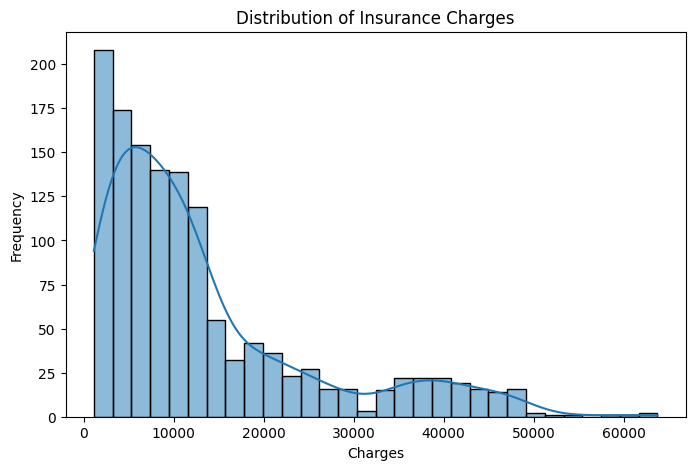

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

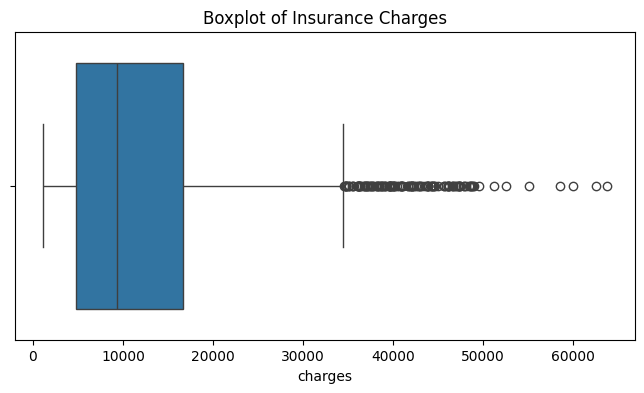

In [19]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["charges"]
)

plt.title("Boxplot of Insurance Charges")

plt.show()

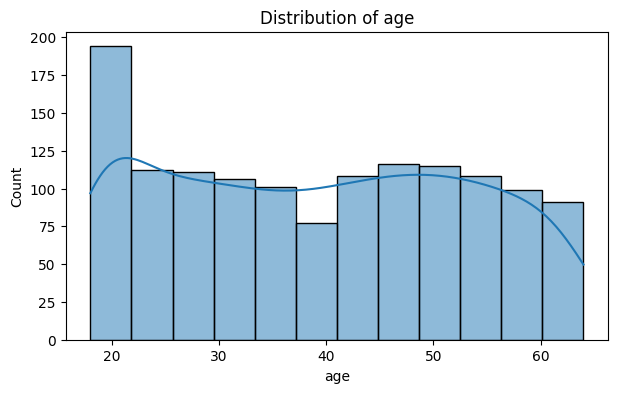

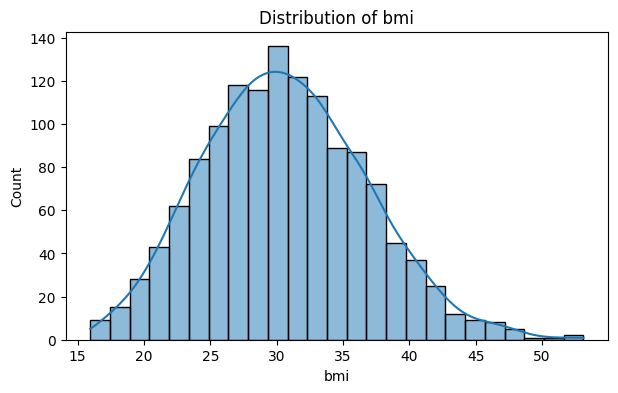

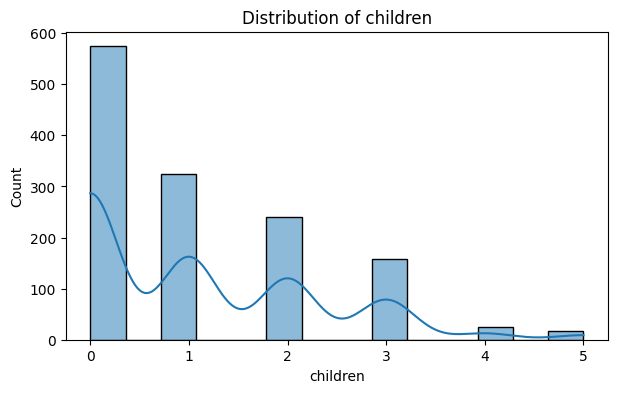

In [20]:
for col in numerical_features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.show()

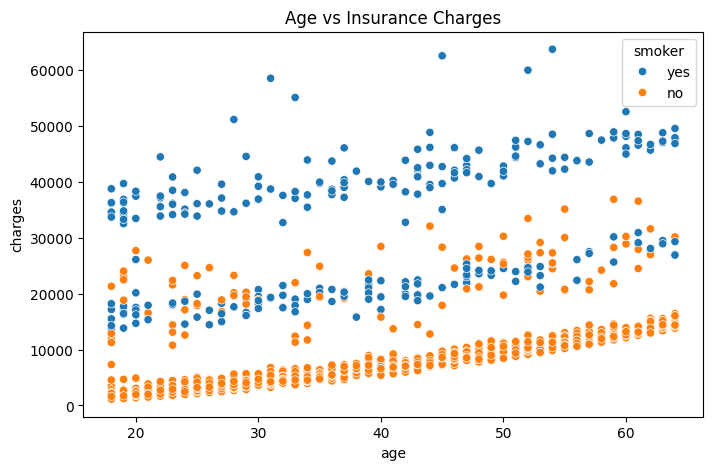

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges")

plt.show()

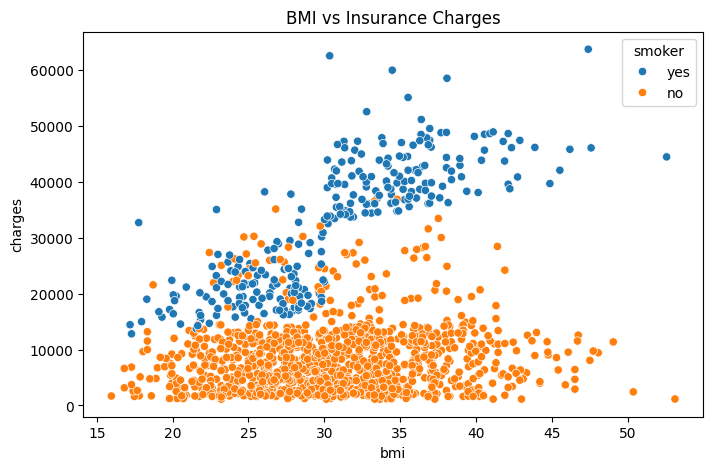

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")

plt.show()

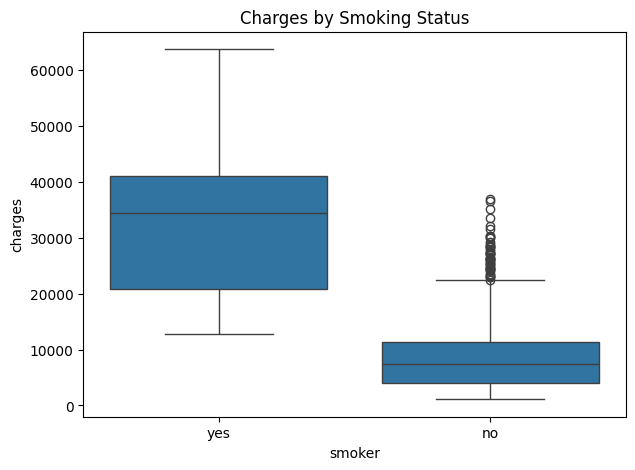

In [23]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Charges by Smoking Status")

plt.show()

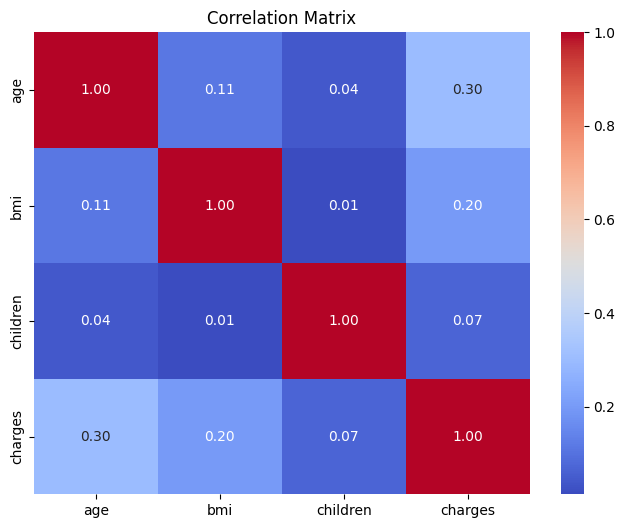

In [24]:
correlation = df[
    numerical_features + ["charges"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
X = df.drop(
    "charges",
    axis=1
)

y = df["charges"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1070
Testing samples: 268


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [29]:
y_pred_linear = linear_model.predict(
    X_test
)

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = mean_squared_error(
    y_test,
    y_pred_linear
) ** 0.5

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
-------------------------
MAE : 4181.194473753649
RMSE: 5796.2846592762735
R²  : 0.7835929767120723


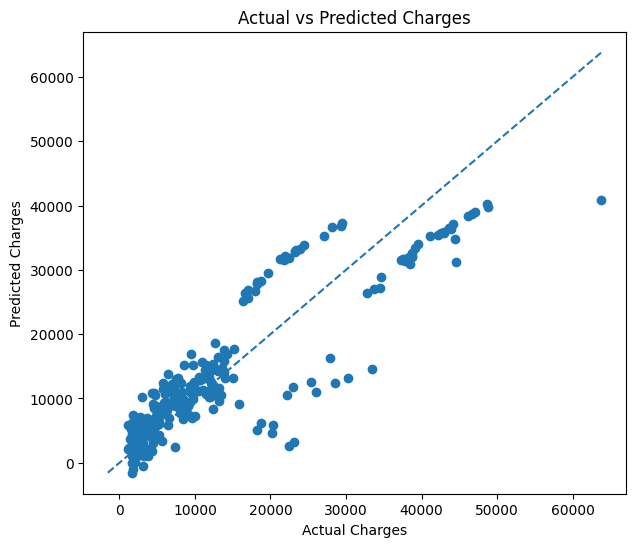

In [31]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_linear
)

minimum = min(
    y_test.min(),
    y_pred_linear.min()
)

maximum = max(
    y_test.max(),
    y_pred_linear.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

In [32]:
import statsmodels.formula.api as smf

ols_model = smf.ols(
    "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)",
    data=df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:38:41   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

In [33]:
fitted_values = ols_model.fittedvalues

residuals = ols_model.resid

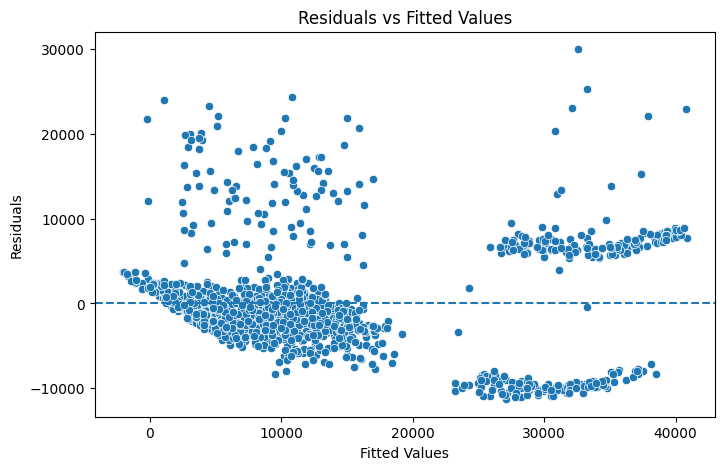

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

In [37]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    residuals,
    ols_model.model.exog
)

print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

LM Statistic: 121.74360137568883
LM p-value: 1.4467175539188856e-22
F Statistic: 16.628612027375237
F p-value: 1.1456058246346406e-23


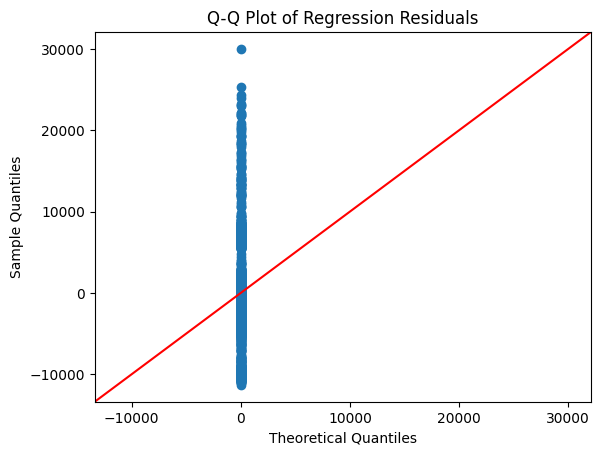

In [38]:
import statsmodels.api as sm

sm.qqplot(
    residuals,
    line="45"
)

plt.title("Q-Q Plot of Regression Residuals")

plt.show()

In [39]:
from scipy import stats

sample_residuals = residuals.sample(
    min(500, len(residuals)),
    random_state=42
)

shapiro_result = stats.shapiro(
    sample_residuals
)

print("Statistic:", shapiro_result.statistic)
print("p-value:", shapiro_result.pvalue)

Statistic: 0.8998918843710911
p-value: 1.4102568841244854e-17


In [40]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(
    residuals
)

print("Durbin-Watson:", dw)

Durbin-Watson: 2.088422998667309


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = pd.get_dummies(
    df.drop("charges", axis=1),
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

X_vif = sm.add_constant(
    X_vif
)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,35.527488
1,age,1.016822
2,bmi,1.106630
3,children,1.004011
4,sex_male,1.008900
5,smoker_yes,1.012074
6,region_northwest,1.518823
7,region_southeast,1.652230
8,region_southwest,1.529411


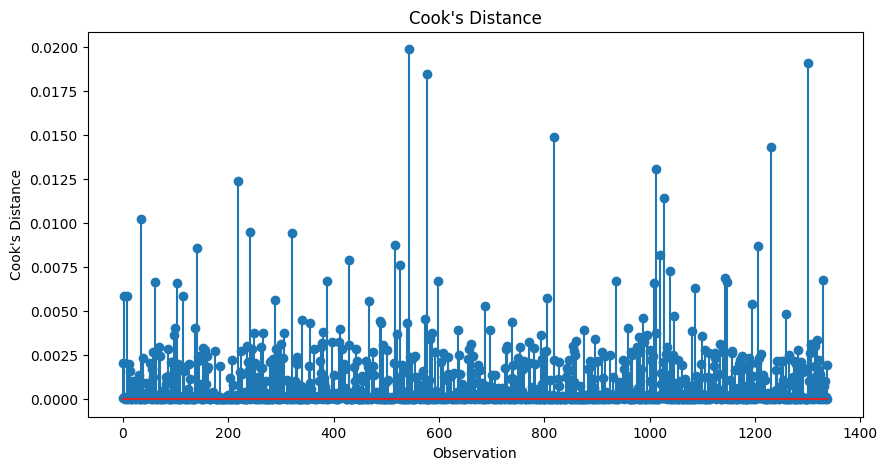

In [42]:
influence = ols_model.get_influence()

cooks_distance = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))

plt.stem(
    range(len(cooks_distance)),
    cooks_distance
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")

plt.title("Cook's Distance")

plt.show()

In [43]:
threshold = 4 / len(df)

influential_points = np.where(
    cooks_distance > threshold
)[0]

print("Threshold:", threshold)

print(
    "Number of potentially influential observations:",
    len(influential_points)
)

Threshold: 0.0029895366218236174
Number of potentially influential observations: 87


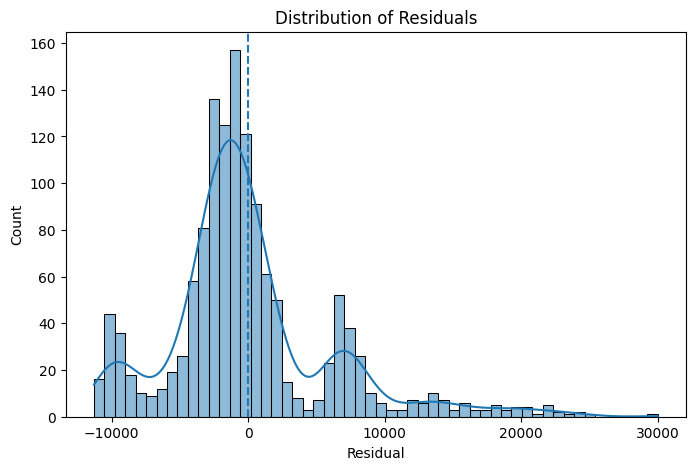

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

In [45]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

ridge_model.fit(
    X_train,
    y_train
)

y_pred_ridge = ridge_model.predict(
    X_test
)

In [46]:
mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
) ** 0.5

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("Ridge Regression")
print("-------------------------")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression
-------------------------
MAE : 4193.195352935269
RMSE: 5800.464937731764
R²  : 0.7832807188145148


In [47]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            Lasso(
                alpha=0.1,
                max_iter=10000
            )
        )
    ]
)

lasso_model.fit(
    X_train,
    y_train
)

y_pred_lasso = lasso_model.predict(
    X_test
)

In [48]:
mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

rmse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
) ** 0.5

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("Lasso Regression")
print("-------------------------")
print("MAE :", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²  :", r2_lasso)

Lasso Regression
-------------------------
MAE : 4181.296901008465
RMSE: 5796.360004355883
R²  : 0.7835873505872939


In [49]:
from sklearn.linear_model import ElasticNet

elastic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            ElasticNet(
                alpha=0.1,
                l1_ratio=0.5,
                max_iter=10000
            )
        )
    ]
)

elastic_model.fit(
    X_train,
    y_train
)

y_pred_elastic = elastic_model.predict(
    X_test
)

In [50]:
mae_elastic = mean_absolute_error(
    y_test,
    y_pred_elastic
)

rmse_elastic = mean_squared_error(
    y_test,
    y_pred_elastic
) ** 0.5

r2_elastic = r2_score(
    y_test,
    y_pred_elastic
)

print("ElasticNet Regression")
print("-------------------------")
print("MAE :", mae_elastic)
print("RMSE:", rmse_elastic)
print("R²  :", r2_elastic)

ElasticNet Regression
-------------------------
MAE : 4788.166684329366
RMSE: 6367.47603139763
R²  : 0.7388400496362719


In [51]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    (
                        "poly",
                        PolynomialFeatures(
                            degree=2,
                            include_bias=False
                        )
                    ),

                    (
                        "scale",
                        StandardScaler()
                    )
                ]
            ),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [52]:
polynomial_model = Pipeline(
    steps=[
        (
            "preprocessor",
            polynomial_preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

polynomial_model.fit(
    X_train,
    y_train
)

y_pred_poly = polynomial_model.predict(
    X_test
)

In [53]:
mae_poly = mean_absolute_error(
    y_test,
    y_pred_poly
)

rmse_poly = mean_squared_error(
    y_test,
    y_pred_poly
) ** 0.5

r2_poly = r2_score(
    y_test,
    y_pred_poly
)

print("Polynomial Regression")
print("-------------------------")
print("MAE :", mae_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
-------------------------
MAE : 4254.274826829182
RMSE: 5841.28018590557
R²  : 0.7802200772760515


In [54]:
models = {
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model,
    "Polynomial Regression": polynomial_model
}

In [55]:
comparison = []

for name, model in models.items():

    predictions = model.predict(
        X_test
    )

    comparison.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "RMSE": mean_squared_error(
            y_test,
            predictions
        ) ** 0.5,
        "R2": r2_score(
            y_test,
            predictions
        )
    })

comparison_df = pd.DataFrame(
    comparison
)

comparison_df.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,4181.194474,5796.284659,0.783593
2,Lasso,4181.296901,5796.360004,0.783587
1,Ridge,4193.195353,5800.464938,0.783281
4,Polynomial Regression,4254.274827,5841.280186,0.780220
3,ElasticNet,4788.166684,6367.476031,0.738840


In [56]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [57]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error"
        }
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "R2 Std": scores["test_R2"].std()
    })

cv_df = pd.DataFrame(
    cv_results
)

cv_df.sort_values(
    "CV R2",
    ascending=False
)

,Model,CV MAE,CV RMSE,CV R2,R2 Std
4,Polynomial Regression,4255.373548,6051.686433,0.742469,0.056412
1,Ridge,4212.482141,6077.518040,0.740268,0.057129
2,Lasso,4203.420924,6077.222999,0.740196,0.057775
0,Linear Regression,4203.412103,6077.226921,0.740196,0.057778
3,ElasticNet,4722.310904,6495.792466,0.707236,0.035974


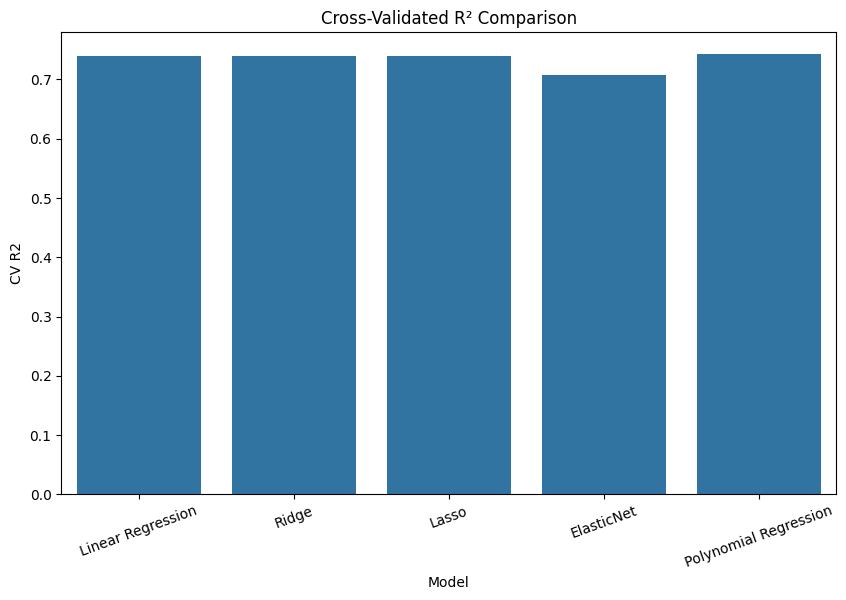

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Model",
    y="CV R2"
)

plt.xticks(rotation=20)

plt.title("Cross-Validated R² Comparison")

plt.show()

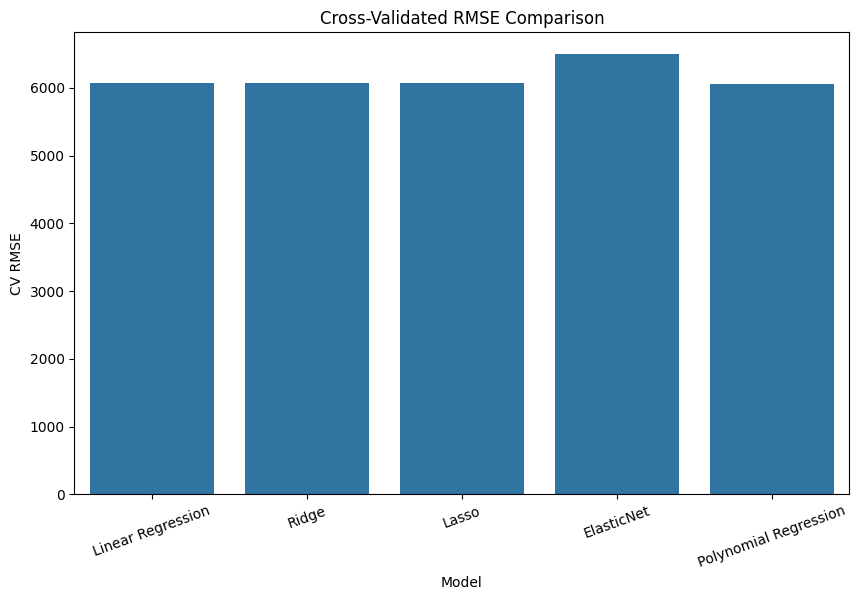

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Model",
    y="CV RMSE"
)

plt.xticks(rotation=20)

plt.title("Cross-Validated RMSE Comparison")

plt.show()

In [60]:
from sklearn.model_selection import GridSearchCV
import numpy as np

ridge_parameters = {
    "model__alpha": np.logspace(
        -3,
        3,
        20
    )
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_parameters,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(
    X_train,
    y_train
)

print(
    "Best Ridge parameters:",
    ridge_grid.best_params_
)

Best Ridge parameters: {'model__alpha': np.float64(0.3359818286283781)}


In [61]:
best_ridge = ridge_grid.best_estimator_

ridge_prediction = best_ridge.predict(
    X_test
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        ridge_prediction
    )
)

print(
    "RMSE:",
    mean_squared_error(
        y_test,
        ridge_prediction
    ) ** 0.5
)

print(
    "R²:",
    r2_score(
        y_test,
        ridge_prediction
    )
)

MAE: 4185.193388350888
RMSE: 5797.637202133146
R²: 0.783491969276803


In [62]:
lasso_parameters = {
    "model__alpha": np.logspace(
        -3,
        1,
        20
    )
}

lasso_grid = GridSearchCV(
    lasso_model,
    lasso_parameters,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(
    X_train,
    y_train
)

print(
    "Best Lasso parameters:",
    lasso_grid.best_params_
)

Best Lasso parameters: {'model__alpha': np.float64(10.0)}


In [63]:
elastic_parameters = {
    "model__alpha": np.logspace(
        -3,
        1,
        15
    ),

    "model__l1_ratio": [
        0.1,
        0.3,
        0.5,
        0.7,
        0.9
    ]
}

elastic_grid = GridSearchCV(
    elastic_model,
    elastic_parameters,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

elastic_grid.fit(
    X_train,
    y_train
)

print(
    "Best ElasticNet parameters:",
    elastic_grid.best_params_
)

Best ElasticNet parameters: {'model__alpha': np.float64(0.003727593720314938), 'model__l1_ratio': 0.9}


In [64]:
final_models = {
    "Linear Regression": linear_model,
    "Ridge Tuned": ridge_grid.best_estimator_,
    "Lasso Tuned": lasso_grid.best_estimator_,
    "ElasticNet Tuned": elastic_grid.best_estimator_,
    "Polynomial Regression": polynomial_model
}

In [65]:
final_results = []

for name, model in final_models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    final_results.append({
        "Model": name,

        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),

        "RMSE": mean_squared_error(
            y_test,
            predictions
        ) ** 0.5,

        "R2": r2_score(
            y_test,
            predictions
        )
    })

final_results_df = pd.DataFrame(
    final_results
)

final_results_df.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Ridge Tuned,4185.193388,5797.637202,0.783492
3,ElasticNet Tuned,4185.957520,5797.898737,0.783472
2,Lasso Tuned,4190.754086,5803.633473,0.783044
4,Polynomial Regression,4254.274827,5841.280186,0.780220


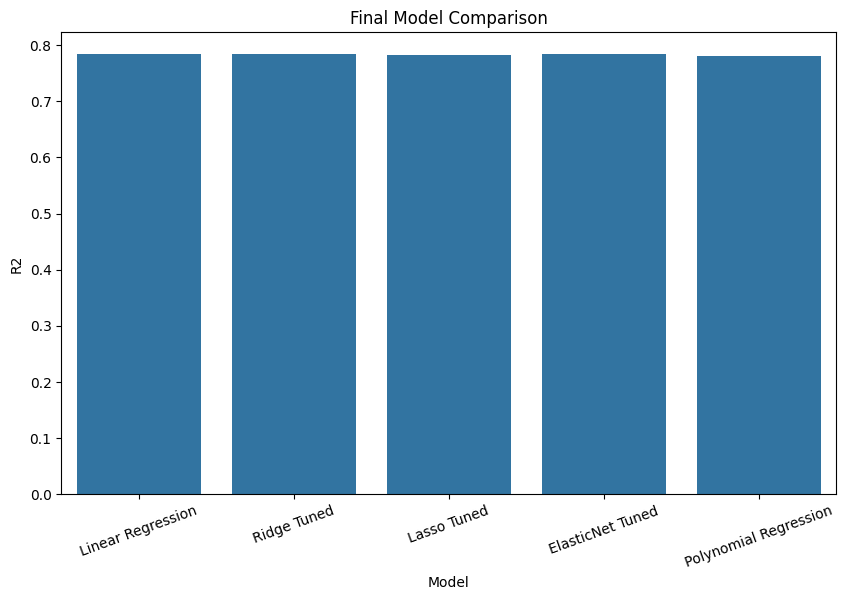

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results_df,
    x="Model",
    y="R2"
)

plt.xticks(rotation=20)

plt.title("Final Model Comparison")

plt.show()

In [68]:
best_model_row = final_results_df.loc[
    final_results_df["R2"].idxmax()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model    Linear Regression
MAE            4181.194474
RMSE           5796.284659
R2                0.783593
Name: 0, dtype: object


In [69]:
best_model = linear_model

In [70]:
best_predictions = best_model.predict(
    X_test
)

final_residuals = (
    y_test - best_predictions
)

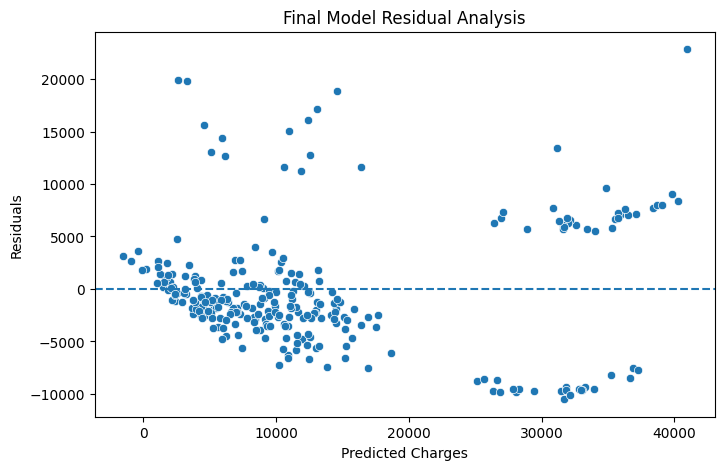

In [71]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=final_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Final Model Residual Analysis")

plt.show()

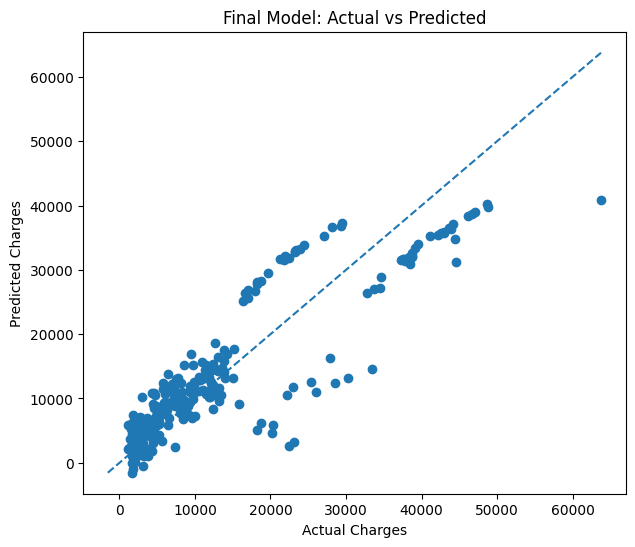

In [72]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    best_predictions
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Final Model: Actual vs Predicted")

plt.show()